<a href="https://colab.research.google.com/github/idhanush2/Assignments/blob/main/asr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd



In [3]:

df = pd.read_csv('/content/drive/MyDrive/Workkkk/Amazon_Sale_Report.csv', low_memory = False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [4]:
df.shape

(128975, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [7]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [8]:
df['Status'].unique()

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [9]:
df['Status'].nunique()

13

In [13]:
df.dropna(inplace = True)

In [14]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [15]:
df['Order ID'] = df['Order ID'].astype('str')
df['SKU'] = df['SKU'].astype('str')
df['ASIN'] = df['ASIN'].astype('str')
df['ship-postal-code'] = df['ship-postal-code'].astype('int')
df['ship-state'] = df['ship-state'].astype('str')


In [16]:
df.set_index('Order ID', inplace = True)
df.head()

,index,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
Order ID,,,,,,,,,,,,,,,,,,,,,
408-4858463-2356347,49051,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,M,...,INR,888.0,RAJAHMUNDRY,ANDHRA PRADESH,533126,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
402-7697834-2682766,49077,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,XXL,...,INR,371.0,CHENNAI,TAMIL NADU,600042,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
402-7031777-0396341,49081,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,XS,...,INR,771.0,NEDUMANGAD,KERALA,695541,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
408-1235521-4337163,49082,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,L,...,INR,0.0,LEH,JAMMU & KASHMIR,194101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
403-3845187-4421165,49083,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,XL,...,INR,690.0,PIMPRI CHINCHWAD,MAHARASHTRA,411027,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [17]:
df.reset_index(inplace = True)
df.head()

,Order ID,index,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,408-4858463-2356347,49051,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,...,INR,888.0,RAJAHMUNDRY,ANDHRA PRADESH,533126,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
1,402-7697834-2682766,49077,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,...,INR,371.0,CHENNAI,TAMIL NADU,600042,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
2,402-7031777-0396341,49081,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,...,INR,771.0,NEDUMANGAD,KERALA,695541,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
3,408-1235521-4337163,49082,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,...,INR,0.0,LEH,JAMMU & KASHMIR,194101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
4,403-3845187-4421165,49083,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,...,INR,690.0,PIMPRI CHINCHWAD,MAHARASHTRA,411027,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [18]:
df.set_index('index', inplace = True)
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
index,,,,,,,,,,,,,,,,,,,,,
49051,408-4858463-2356347,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,M,...,INR,888.0,RAJAHMUNDRY,ANDHRA PRADESH,533126,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49077,402-7697834-2682766,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,XXL,...,INR,371.0,CHENNAI,TAMIL NADU,600042,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49081,402-7031777-0396341,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,XS,...,INR,771.0,NEDUMANGAD,KERALA,695541,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49082,408-1235521-4337163,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,L,...,INR,0.0,LEH,JAMMU & KASHMIR,194101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49083,403-3845187-4421165,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,XL,...,INR,690.0,PIMPRI CHINCHWAD,MAHARASHTRA,411027,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order ID            19379 non-null  object 
 1   Date                19379 non-null  object 
 2   Status              19379 non-null  object 
 3   Fulfilment          19379 non-null  object 
 4   Sales Channel       19379 non-null  object 
 5   ship-service-level  19379 non-null  object 
 6   Style               19379 non-null  object 
 7   SKU                 19379 non-null  object 
 8   Category            19379 non-null  object 
 9   Size                19379 non-null  object 
 10  ASIN                19379 non-null  object 
 11  Courier Status      19379 non-null  object 
 12  Qty                 19379 non-null  int64  
 13  currency            19379 non-null  object 
 14  Amount              19379 non-null  float64
 15  ship-city           19379 non-null  object 
 16  ship

In [30]:
df['Order ID'] = df['Order ID'].astype(str)


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order ID            19379 non-null  object 
 1   Date                19379 non-null  object 
 2   Status              19379 non-null  object 
 3   Fulfilment          19379 non-null  object 
 4   Sales Channel       19379 non-null  object 
 5   ship-service-level  19379 non-null  object 
 6   Style               19379 non-null  object 
 7   SKU                 19379 non-null  object 
 8   Category            19379 non-null  object 
 9   Size                19379 non-null  object 
 10  ASIN                19379 non-null  object 
 11  Courier Status      19379 non-null  object 
 12  Qty                 19379 non-null  int64  
 13  currency            19379 non-null  object 
 14  Amount              19379 non-null  float64
 15  ship-city           19379 non-null  object 
 16  ship

In [33]:
df['Status'] = df['Status'].astype('category')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Order ID            19379 non-null  object  
 1   Date                19379 non-null  object  
 2   Status              19379 non-null  category
 3   Fulfilment          19379 non-null  object  
 4   Sales Channel       19379 non-null  object  
 5   ship-service-level  19379 non-null  object  
 6   Style               19379 non-null  object  
 7   SKU                 19379 non-null  object  
 8   Category            19379 non-null  object  
 9   Size                19379 non-null  object  
 10  ASIN                19379 non-null  object  
 11  Courier Status      19379 non-null  object  
 12  Qty                 19379 non-null  int64   
 13  currency            19379 non-null  object  
 14  Amount              19379 non-null  float64 
 15  ship-city           19379 non-null  

In [39]:
df['Order ID'] = df['Order ID'].astype(str).str.replace('-', '').astype(int)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Order ID            19379 non-null  int64   
 1   Date                19379 non-null  object  
 2   Status              19379 non-null  category
 3   Fulfilment          19379 non-null  object  
 4   Sales Channel       19379 non-null  object  
 5   ship-service-level  19379 non-null  object  
 6   Style               19379 non-null  object  
 7   SKU                 19379 non-null  object  
 8   Category            19379 non-null  object  
 9   Size                19379 non-null  object  
 10  ASIN                19379 non-null  object  
 11  Courier Status      19379 non-null  object  
 12  Qty                 19379 non-null  int64   
 13  currency            19379 non-null  object  
 14  Amount              19379 non-null  float64 
 15  ship-city           19379 non-null  

In [42]:
df = df.astype({
    'Date': 'datetime64[ns]',
    'ship-state': 'category',
    'Size': 'category',
    'ship-country': 'category',
    'ship-city': 'category',
    'Courier Status': 'str'
})


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            19379 non-null  int64         
 1   Date                19379 non-null  datetime64[ns]
 2   Status              19379 non-null  category      
 3   Fulfilment          19379 non-null  object        
 4   Sales Channel       19379 non-null  object        
 5   ship-service-level  19379 non-null  object        
 6   Style               19379 non-null  object        
 7   SKU                 19379 non-null  object        
 8   Category            19379 non-null  object        
 9   Size                19379 non-null  category      
 10  ASIN                19379 non-null  object        
 11  Courier Status      19379 non-null  object        
 12  Qty                 19379 non-null  int64         
 13  currency            19379 non-null  object    

In [44]:
df.head(4)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
index,,,,,,,,,,,,,,,,,,,,,
49051,40848584632356347,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,M,...,1,INR,888.0,RAJAHMUNDRY,ANDHRA PRADESH,533126,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
49077,40276978342682766,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,XXL,...,1,INR,371.0,CHENNAI,TAMIL NADU,600042,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
49081,40270317770396341,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,XS,...,1,INR,771.0,NEDUMANGAD,KERALA,695541,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
49082,40812355214337163,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,L,...,1,INR,0.0,LEH,JAMMU & KASHMIR,194101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship


In [45]:
df['ship-country'].unique()

['IN']
Categories (1, object): ['IN']

In [46]:
df['B2B'].unique()

array([False,  True])

In [47]:
df.drop('B2B', axis = 1, inplace = True)

In [48]:
df.drop('Style', axis = 1, inplace = True)

In [50]:
df.drop('Fulfilment', axis = 1, inplace = True)

In [52]:
df['currency'].unique()

array(['INR'], dtype=object)

In [53]:
df.drop('currency', axis = 1, inplace = True)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            19379 non-null  int64         
 1   Date                19379 non-null  datetime64[ns]
 2   Status              19379 non-null  category      
 3   Sales Channel       19379 non-null  object        
 4   ship-service-level  19379 non-null  object        
 5   SKU                 19379 non-null  object        
 6   Category            19379 non-null  object        
 7   Size                19379 non-null  category      
 8   ASIN                19379 non-null  object        
 9   Courier Status      19379 non-null  object        
 10  Qty                 19379 non-null  int64         
 11  Amount              19379 non-null  float64       
 12  ship-city           19379 non-null  category      
 13  ship-state          19379 non-null  category  

In [55]:
df['ship-service-level'].unique()

array(['Standard'], dtype=object)

In [56]:
df.drop('ship-service-level', axis = 1, inplace = True)

In [59]:
df.drop('Size', axis = 1, inplace = True)

In [60]:
df['fulfilled-by'].unique()

array(['Easy Ship'], dtype=object)

In [61]:
df.drop('fulfilled-by', axis = 1, inplace = True)

In [64]:
df['Sales Channel '].unique()

array(['Amazon.in'], dtype=object)

In [65]:
df.drop('Sales Channel ', axis = 1, inplace = True)

In [68]:
df = df.astype({
    'SKU': 'category',
    'Category': 'category',
    'ASIN': 'category',
    'Courier Status': 'category',
    'promotion-ids': 'category',
    'Courier Status': 'category'
})

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          19379 non-null  int64         
 1   Date              19379 non-null  datetime64[ns]
 2   Status            19379 non-null  category      
 3   SKU               19379 non-null  category      
 4   Category          19379 non-null  category      
 5   ASIN              19379 non-null  category      
 6   Courier Status    19379 non-null  category      
 7   Qty               19379 non-null  int64         
 8   Amount            19379 non-null  float64       
 9   ship-city         19379 non-null  category      
 10  ship-state        19379 non-null  category      
 11  ship-postal-code  19379 non-null  int64         
 12  ship-country      19379 non-null  category      
 13  promotion-ids     19379 non-null  category      
dtypes: category(9), dateti

In [70]:
df.drop_duplicates(inplace = True)

In [71]:
df.shape

(19379, 14)

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Amount', ylabel='Count'>

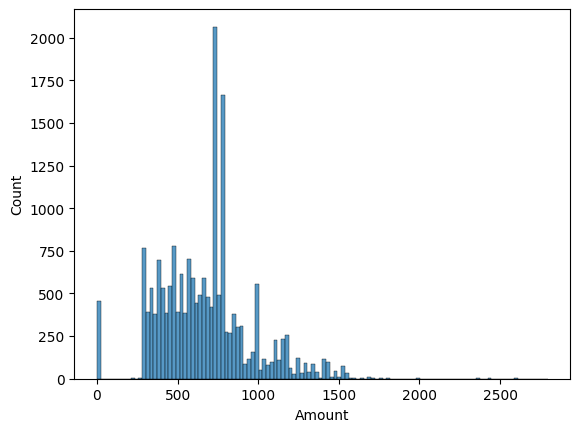

In [74]:
sns.histplot(df['Amount'])

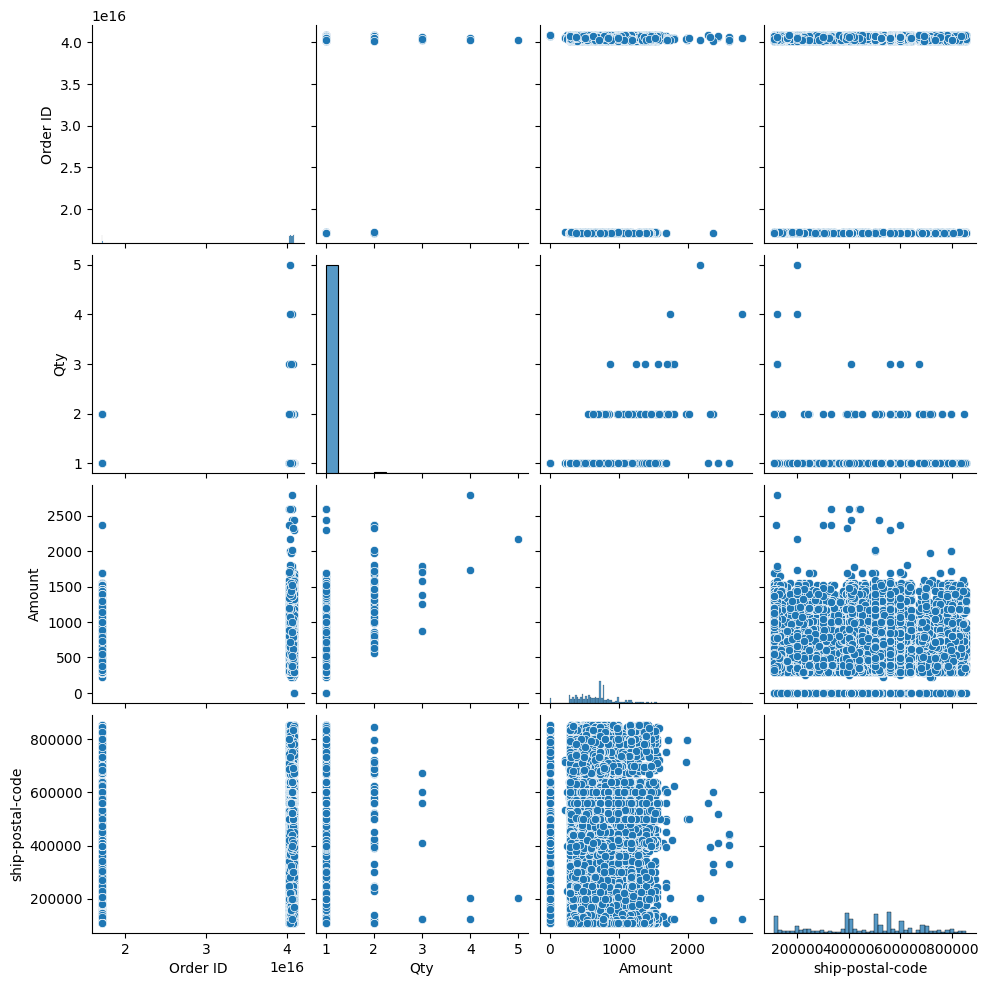

In [75]:
sns.pairplot(df)

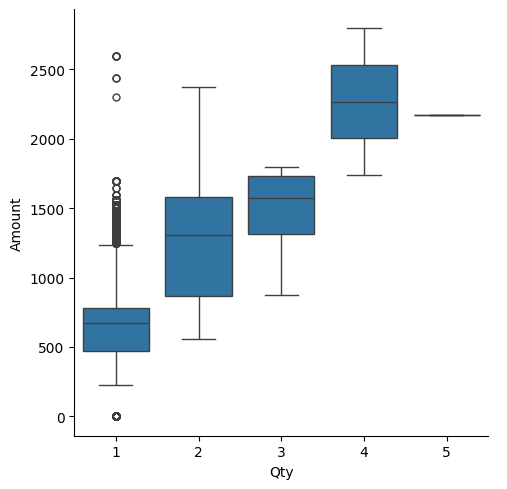

In [76]:
sns.catplot(x = 'Qty', y ='Amount', data = df, kind = 'box')

<Axes: xlabel='Qty', ylabel='Amount'>

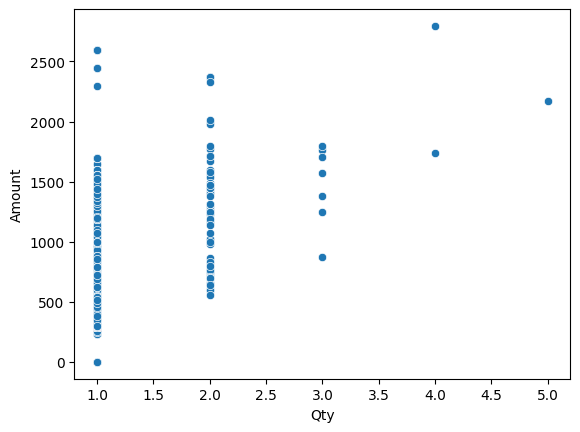

In [77]:
sns.scatterplot(x = 'Qty', y = 'Amount', data = df)

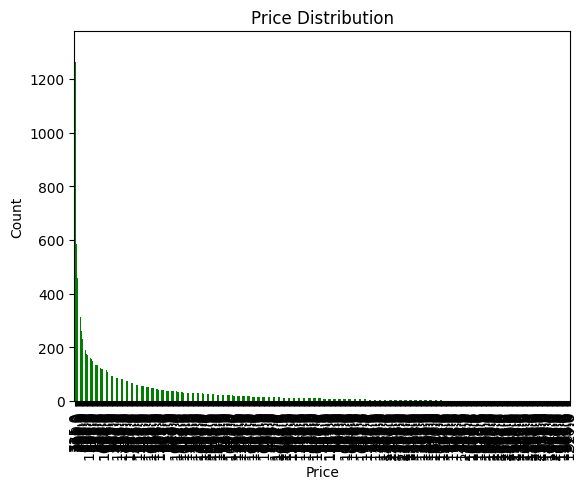

In [78]:
df.Amount.value_counts()
df.Amount.value_counts().plot(kind = 'bar', color = 'g')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.show()